In [2]:
%load_ext autoreload
%autoreload 2


import ipywidgets as widgets
import sys
from pathlib import Path
import os
import importlib


module_path='preprocessing/day_intervals_preproc'
if module_path not in sys.path:
    sys.path.append(module_path)

module_path='utils'
if module_path not in sys.path:
    sys.path.append(module_path)
    
module_path='preprocessing/hosp_module_preproc'
if module_path not in sys.path:
    sys.path.append(module_path)
    
module_path='model'
if module_path not in sys.path:
    sys.path.append(module_path)
#print(sys.path)
root_dir = os.path.dirname(os.path.abspath('UserInterface.ipynb'))
import day_intervals_cohort
from day_intervals_cohort import *

import day_intervals_cohort_v2
from day_intervals_cohort_v2 import *

import data_generation_icu

import data_generation
import evaluation

import feature_selection_hosp
from feature_selection_hosp import *

# import train
# from train import *


import ml_models
from ml_models import *

import dl_train
from dl_train import *

import tokenization
from tokenization import *


import behrt_train
from behrt_train import *

import feature_selection_icu
from feature_selection_icu import *
import fairness
import callibrate_output

importlib.reload(day_intervals_cohort)
import day_intervals_cohort
from day_intervals_cohort import *

importlib.reload(day_intervals_cohort_v2)
import day_intervals_cohort_v2
from day_intervals_cohort_v2 import *

importlib.reload(data_generation_icu)
import data_generation_icu
importlib.reload(data_generation)
import data_generation

importlib.reload(feature_selection_hosp)
import feature_selection_hosp
from feature_selection_hosp import *

importlib.reload(feature_selection_icu)
import feature_selection_icu
from feature_selection_icu import *

importlib.reload(tokenization)
import tokenization
from tokenization import *

importlib.reload(ml_models)
import ml_models
from ml_models import *

importlib.reload(dl_train)
import dl_train
from dl_train import *

importlib.reload(behrt_train)
import behrt_train
from behrt_train import *

importlib.reload(fairness)
import fairness

importlib.reload(callibrate_output)
import callibrate_output

importlib.reload(evaluation)
import evaluation


In [4]:
print("Please select the approriate version of MIMIC-IV for which you have downloaded data ?")
version = widgets.RadioButtons(options=['Version 1','Version 2'],value='Version 2')
display(version)

print("Please select what prediction task you want to perform ?")
radio_input4 = widgets.RadioButtons(options=['Mortality','Length of Stay','Readmission','Phenotype'],value='Length of Stay')
display(radio_input4)

Please select the approriate version of MIMIC-IV for which you have downloaded data ?


RadioButtons(index=1, options=('Version 1', 'Version 2'), value='Version 2')

Please select what prediction task you want to perform ?


RadioButtons(index=1, options=('Mortality', 'Length of Stay', 'Readmission', 'Phenotype'), value='Length of St…

In [6]:
if radio_input4.value=='Length of Stay':
    radio_input2 = widgets.RadioButtons(options=['Length of Stay ge 3','Length of Stay ge 7','Custom'],value='Length of Stay ge 7')
    display(radio_input2)
    text1=widgets.IntSlider(
    value=3,
    min=1,
    max=10,
    step=1,
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)
    display(widgets.HBox([widgets.Label('Length of stay ge (in days)',layout={'width': '180px'}), text1]))
elif radio_input4.value=='Readmission':
    radio_input2 = widgets.RadioButtons(options=['30 Day Readmission','60 Day Readmission','90 Day Readmission','120 Day Readmission','Custom'],value='30 Day Readmission')
    display(radio_input2)
    text1=widgets.IntSlider(
    value=30,
    min=10,
    max=150,
    step=10,
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Readmission after (in days)',layout={'width': '180px'}), text1]))
elif radio_input4.value=='Phenotype':
    radio_input2 = widgets.RadioButtons(options=['Heart Failure in 30 days','CAD in 30 days','CKD in 30 days','COPD in 30 days'],value='Heart Failure in 30 days')
    display(radio_input2)
elif radio_input4.value=='Mortality':
    radio_input2 = widgets.RadioButtons(options=['Mortality'],value='Mortality')
    #display(radio_input2)

print("Extract Data")
print("Please select below if you want to work with ICU or Non-ICU data ?")
radio_input1 = widgets.RadioButtons(options=['ICU', 'Non-ICU'],value='ICU')
display(radio_input1)

print("Please select if you want to perform choosen prediction task for a specific disease.")
radio_input3 = widgets.RadioButtons(options=['No Disease Filter','Heart Failure','CKD','CAD','COPD'],value='No Disease Filter')
display(radio_input3)

RadioButtons(index=1, options=('Length of Stay ge 3', 'Length of Stay ge 7', 'Custom'), value='Length of Stay …

Extract Data
Please select below if you want to work with ICU or Non-ICU data ?


RadioButtons(options=('ICU', 'Non-ICU'), value='ICU')

Please select if you want to perform choosen prediction task for a specific disease.


RadioButtons(options=('No Disease Filter', 'Heart Failure', 'CKD', 'CAD', 'COPD'), value='No Disease Filter')

In [7]:
disease_label=""
time=0
label=radio_input4.value

if label=='Readmission':
    if radio_input2.value=='Custom':
        time=text1.value
    else:
        time=int(radio_input2.value.split()[0])
elif label=='Length of Stay':
    if radio_input2.value=='Custom':
        time=text1.value
    else:
        time=int(radio_input2.value.split()[4])

if label=='Phenotype':    
    if radio_input2.value=='Heart Failure in 30 days':
        label='Readmission'
        time=30
        disease_label='I50'
    elif radio_input2.value=='CAD in 30 days':
        label='Readmission'
        time=30
        disease_label='I25'
    elif radio_input2.value=='CKD in 30 days':
        label='Readmission'
        time=30
        disease_label='N18'
    elif radio_input2.value=='COPD in 30 days':
        label='Readmission'
        time=30
        disease_label='J44'
    
data_icu=radio_input1.value=="ICU"
data_mort=label=="Mortality"
data_admn=label=='Readmission'
data_los=label=='Length of Stay'
        

if (radio_input3.value=="Heart Failure"):
    icd_code='I50'
elif (radio_input3.value=="CKD"):
    icd_code='N18'
elif (radio_input3.value=="COPD"):
    icd_code='J44'
elif (radio_input3.value=="CAD"):
    icd_code='I25'
else:
    icd_code='No Disease Filter'

if version.value=='Version 1':
    version_path="mimiciv/1.0"
    cohort_output = day_intervals_cohort.extract_data(radio_input1.value,label,time,icd_code, root_dir,disease_label)
elif version.value=='Version 2':
    version_path="mimiciv/2.2"
    cohort_output = day_intervals_cohort_v2.extract_data(radio_input1.value,label,time,icd_code, root_dir,disease_label)

===========MIMIC-IV v2.0============
EXTRACTING FOR: | ICU | LENGTH OF STAY | 7 |
[ LOS LABELS FINISHED ]
[ COHORT SUCCESSFULLY SAVED ]
[ SUMMARY SUCCESSFULLY SAVED ]
Length of Stay FOR ICU DATA
# Admission Records: 8111
# Patients: 6132
# Positive cases: 867
# Negative cases: 7244


In [8]:
print("Feature Selection")
if data_icu:
    print("Which Features you want to include for cohort?")
    check_input1 = widgets.Checkbox(description='Diagnosis')
    display(check_input1)
    check_input2 = widgets.Checkbox(description='Output Events')
    display(check_input2)
    check_input3 = widgets.Checkbox(description='Chart Events(Labs and Vitals)')
    display(check_input3)
    check_input4 = widgets.Checkbox(description='Procedures')
    display(check_input4)
    check_input5 = widgets.Checkbox(description='Medications')
    display(check_input5)
else:
    print("Which Features you want to include for cohort?")
    check_input1 = widgets.Checkbox(description='Diagnosis')
    display(check_input1)
    check_input2 = widgets.Checkbox(description='Labs')
    display(check_input2)
    check_input3 = widgets.Checkbox(description='Procedures')
    display(check_input3)
    check_input4 = widgets.Checkbox(description='Medications')
    display(check_input4)
print("**Please run below cell to extract selected features**")

Feature Selection
Which Features you want to include for cohort?


Checkbox(value=False, description='Diagnosis')

Checkbox(value=False, description='Output Events')

Checkbox(value=False, description='Chart Events(Labs and Vitals)')

Checkbox(value=False, description='Procedures')

Checkbox(value=False, description='Medications')

**Please run below cell to extract selected features**


In [9]:
if data_icu:
    diag_flag=check_input1.value
    out_flag=check_input2.value
    chart_flag=check_input3.value
    proc_flag=check_input4.value
    med_flag=check_input5.value
    feature_icu(cohort_output, version_path,diag_flag,out_flag,chart_flag,proc_flag,med_flag)
else:
    diag_flag=check_input1.value
    lab_flag=check_input2.value
    proc_flag=check_input3.value
    med_flag=check_input4.value
    feature_nonicu(cohort_output, version_path,diag_flag,lab_flag,proc_flag,med_flag)

[EXTRACTING DIAGNOSIS DATA]
# unique ICD-9 codes 3585
# unique ICD-10 codes 4364
# unique ICD-10 codes (After converting ICD-9 to ICD-10) 4737
# unique ICD-10 codes (After clinical gruping ICD-10 codes) 1120
# Admissions:   8110
Total rows 136382
[SUCCESSFULLY SAVED DIAGNOSIS DATA]
[EXTRACTING MEDICATIONS DATA]
# of unique type of drug:  154
# Admissions:   7677
# Total rows 533512
[SUCCESSFULLY SAVED MEDICATIONS DATA]


In [10]:
if data_icu:
    if diag_flag:
        print("Do you want to group ICD 10 DIAG codes ?")
        radio_input4 = widgets.RadioButtons(options=['Keep both ICD-9 and ICD-10 codes','Convert ICD-9 to ICD-10 codes','Convert ICD-9 to ICD-10 and group ICD-10 codes'],value='Convert ICD-9 to ICD-10 and group ICD-10 codes',layout={'width': '100%'})
        display(radio_input4)   
    
else:
    if diag_flag:
        print("Do you want to group ICD 10 DIAG codes ?")
        radio_input4 = widgets.RadioButtons(options=['Keep both ICD-9 and ICD-10 codes','Convert ICD-9 to ICD-10 codes','Convert ICD-9 to ICD-10 and group ICD-10 codes'],value='Convert ICD-9 to ICD-10 and group ICD-10 codes',layout={'width': '100%'})
        display(radio_input4)     
    if med_flag:
        print("Do you want to group Medication codes to use Non propietary names?")
        radio_input5 = widgets.RadioButtons(options=['Yes','No'],value='Yes',layout={'width': '100%'})
        display(radio_input5)
    if proc_flag:
        print("Which ICD codes for Procedures you want to keep in data?")
        radio_input6 = widgets.RadioButtons(options=['ICD-9 and ICD-10','ICD-10'],value='ICD-10',layout={'width': '100%'})
        display(radio_input6)
print("**Please run below cell to perform feature preprocessing**")

Do you want to group ICD 10 DIAG codes ?


RadioButtons(index=2, layout=Layout(width='100%'), options=('Keep both ICD-9 and ICD-10 codes', 'Convert ICD-9…

**Please run below cell to perform feature preprocessing**


In [11]:
group_diag=False
group_med=False
group_proc=False
if data_icu:
    if diag_flag:
        group_diag=radio_input4.value
    preprocess_features_icu(cohort_output, diag_flag, group_diag,False,False,False,0,0)
else:
    if diag_flag:
        group_diag=radio_input4.value
    if med_flag:
        group_med=radio_input5.value
    if proc_flag:
        group_proc=radio_input6.value
    preprocess_features_hosp(cohort_output, diag_flag,proc_flag,med_flag,False,group_diag,group_med,group_proc,False,False,0,0)

[PROCESSING DIAGNOSIS DATA]
Total number of rows 129050
[SUCCESSFULLY SAVED DIAGNOSIS DATA]


In [12]:
if data_icu:
    generate_summary_icu(diag_flag,proc_flag,med_flag,out_flag,chart_flag)
else:
    generate_summary_hosp(diag_flag,proc_flag,med_flag,lab_flag)

[GENERATING FEATURE SUMMARY]
[SUCCESSFULLY SAVED FEATURE SUMMARY]


In [15]:
if data_icu:
    if diag_flag:
        print("Do you want to do Feature Selection for Diagnosis \n (If yes, please edit list of codes in ./data/summary/diag_features.csv)")
        radio_input4 = widgets.RadioButtons(options=['Yes','No'],value='Yes')
        display(radio_input4)       
    if med_flag:
        print("Do you want to do Feature Selection for Medication \n (If yes, please edit list of codes in ./data/summary/med_features.csv)")
        radio_input5 = widgets.RadioButtons(options=['Yes','No'],value='Yes')
        display(radio_input5)   
    if proc_flag:
        print("Do you want to do Feature Selection for Procedures \n (If yes, please edit list of codes in ./data/summary/proc_features.csv)")
        radio_input6 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input6)   
    if out_flag:
        print("Do you want to do Feature Selection for Output event \n (If yes, please edit list of codes in ./data/summary/out_features.csv)")
        radio_input7 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input7)  
    if chart_flag:
        print("Do you want to do Feature Selection for Chart events \n (If yes, please edit list of codes in ./data/summary/chart_features.csv)")
        radio_input8 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input8)  
else:
    if diag_flag:
        print("Do you want to do Feature Selection for Diagnosis \n (If yes, please edit list of codes in ./data/summary/diag_features.csv)")
        radio_input4 = widgets.RadioButtons(options=['Yes','No'],value='Yes')
        display(radio_input4)         
    if med_flag:
        print("Do you want to do Feature Selection for Medication \n (If yes, please edit list of codes in ./data/summary/med_features.csv)")
        radio_input5 = widgets.RadioButtons(options=['Yes','No'],value='Yes')
        display(radio_input5)   
    if proc_flag:
        print("Do you want to do Feature Selection for Procedures \n (If yes, please edit list of codes in ./data/summary/proc_features.csv)")
        radio_input6 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input6)   
    if lab_flag:
        print("Do you want to do Feature Selection for Labs \n (If yes, please edit list of codes in ./data/summary/lab_features.csv)")
        radio_input7 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input7)   
print("**Please run below cell to perform feature selection**")

Do you want to do Feature Selection for Diagnosis 
 (If yes, please edit list of codes in ./data/summary/diag_features.csv)


RadioButtons(options=('Yes', 'No'), value='Yes')

Do you want to do Feature Selection for Medication 
 (If yes, please edit list of codes in ./data/summary/med_features.csv)


RadioButtons(options=('Yes', 'No'), value='Yes')

**Please run below cell to perform feature selection**


In [16]:
select_diag=False
select_med=False
select_proc=False
select_lab=False
select_out=False
select_chart=False

if data_icu:
    if diag_flag:
        select_diag=radio_input4.value == 'Yes'
    if med_flag:
        select_med=radio_input5.value == 'Yes'
    if proc_flag:
        select_proc=radio_input6.value == 'Yes'
    if out_flag:
        select_out=radio_input7.value == 'Yes'
    if chart_flag:
        select_chart=radio_input8.value == 'Yes'
    features_selection_icu(cohort_output, diag_flag,proc_flag,med_flag,out_flag, chart_flag,select_diag,select_med,select_proc,select_out,select_chart)
else:
    if diag_flag:
        select_diag=radio_input4.value == 'Yes'
    if med_flag:
        select_med=radio_input5.value == 'Yes'
    if proc_flag:
        select_proc=radio_input6.value == 'Yes'
    if lab_flag:
        select_lab=radio_input7.value == 'Yes'
    features_selection_hosp(cohort_output, diag_flag,proc_flag,med_flag,lab_flag,select_diag,select_med,select_proc,select_lab)

[FEATURE SELECTION DIAGNOSIS DATA]
Total number of rows 129050
[SUCCESSFULLY SAVED DIAGNOSIS DATA]
[FEATURE SELECTION MEDICATIONS DATA]
Total number of rows 533512
[SUCCESSFULLY SAVED MEDICATIONS DATA]


In [17]:
if data_icu:
    if chart_flag:
        print("Outlier removal in values of chart events ?")
        layout = widgets.Layout(width='100%', height='40px') #set width and height

        radio_input5 = widgets.RadioButtons(options=['No outlier detection','Impute Outlier (default:98)','Remove outliers (default:98)'],value='No outlier detection',layout=layout)
        display(radio_input5)
        outlier=widgets.IntSlider(
        value=98,
        min=90,
        max=99,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        left_outlier=widgets.IntSlider(
        value=0,
        min=0,
        max=10,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        #display(oulier)
        display(widgets.HBox([widgets.Label('Right Outlier Threshold',layout={'width': '150px'}), outlier]))
        display(widgets.HBox([widgets.Label('Left Outlier Threshold',layout={'width': '150px'}), left_outlier]))
    
else:      
    if lab_flag:
        print("Outlier removal in values of lab events ?")
        layout = widgets.Layout(width='100%', height='40px') #set width and height

        radio_input7 = widgets.RadioButtons(options=['No outlier detection','Impute Outlier (default:98)','Remove outliers (default:98)'],value='No outlier detection',layout=layout)
        display(radio_input7)
        outlier=widgets.IntSlider(
        value=98,
        min=90,
        max=99,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        left_outlier=widgets.IntSlider(
        value=0,
        min=0,
        max=10,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        #display(oulier)
        display(widgets.HBox([widgets.Label('Right Outlier Threshold',layout={'width': '150px'}), outlier]))
        display(widgets.HBox([widgets.Label('Left Outlier Threshold',layout={'width': '150px'}), left_outlier]))
print("**Please run below cell to perform feature preprocessing**")

**Please run below cell to perform feature preprocessing**


In [18]:
thresh=0
if data_icu:
    if chart_flag:
        clean_chart=radio_input5.value!='No outlier detection'
        impute_outlier_chart=radio_input5.value=='Impute Outlier (default:98)'
        thresh=outlier.value
        left_thresh=left_outlier.value
        preprocess_features_icu(cohort_output, False, False,chart_flag,clean_chart,impute_outlier_chart,thresh,left_thresh)
    else:
        preprocess_features_icu(cohort_output, False, False,False,False,False,0,0)
else:
    if lab_flag:
        clean_lab=radio_input7.value!='No outlier detection'
        impute_outlier=radio_input7.value=='Impute Outlier (default:98)'
        thresh=outlier.value
        left_thresh=left_outlier.value
    preprocess_features_hosp(cohort_output, False,False,False,lab_flag,False,False,False,clean_lab,impute_outlier,thresh,left_thresh)

In [20]:
print("=======Time-series Data Represenation=======")

print("Length of data to be included for time-series prediction ?")
if(data_mort):
    radio_input8 = widgets.RadioButtons(options=['First 72 hours','First 48 hours','First 24 hours','Custom'],value='First 72 hours')
    display(radio_input8)
    text2=widgets.IntSlider(
    value=72,
    min=24,
    max=72,
    step=1,
    description='Fisrt',
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Fisrt (in hours):',layout={'width': '150px'}), text2]))
elif(data_admn):
    radio_input8 = widgets.RadioButtons(options=['Last 72 hours','Last 48 hours','Last 24 hours','Custom'],value='Last 72 hours')
    display(radio_input8)
    text2=widgets.IntSlider(
    value=72,
    min=24,
    max=72,
    step=1,
    description='Last',
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Last (in hours):',layout={'width': '150px'}), text2]))
elif(data_los):
    radio_input8 = widgets.RadioButtons(options=['First 12 hours','First 24 hours','Custom'],value='First 12 hours')
    display(radio_input8)
    text2=widgets.IntSlider(
    value=72,
    min=12,
    max=72,
    step=1,
    description='First',
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Fisrt (in hours):',layout={'width': '150px'}), text2]))
    
    
print("What time bucket size you want to choose ?")
radio_input7 = widgets.RadioButtons(options=['1 hour','2 hour','3 hour','4 hour','5 hour','Custom'],value='1 hour')
display(radio_input7)
text1=widgets.IntSlider(
    value=1,
    min=1,
    max=6,
    step=1,
    disabled=False
    )
#display(text1)
display(widgets.HBox([widgets.Label('Bucket Size (in hours):',layout={'width': '150px'}), text1]))
print("Do you want to forward fill and mean or median impute lab/chart values to form continuous data signal?")
radio_impute = widgets.RadioButtons(options=['No Imputation', 'forward fill and mean','forward fill and median'],value='forward fill and median')
display(radio_impute)   

radio_input6 = widgets.RadioButtons(options=['0 hours','2 hours','4 hours','6 hours'],value='0 hours')
if(data_mort):
    print("If you have choosen mortality prediction task, then what prediction window length you want to keep?")
    radio_input6 = widgets.RadioButtons(options=['2 hours','4 hours','6 hours','8 hours','Custom'],value='2 hours')
    display(radio_input6)
    text3=widgets.IntSlider(
    value=2,
    min=2,
    max=8,
    step=1,
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Prediction window (in hours)',layout={'width': '180px'}), text3]))
print("**Please run below cell to perform time-series represenation and save in data dictionaries**")

=======Time-series Data Represenation=======
Length of data to be included for time-series prediction ?


RadioButtons(options=('First 12 hours', 'First 24 hours', 'Custom'), value='First 12 hours')

What time bucket size you want to choose ?


RadioButtons(options=('1 hour', '2 hour', '3 hour', '4 hour', '5 hour', 'Custom'), value='1 hour')

Do you want to forward fill and mean or median impute lab/chart values to form continuous data signal?


RadioButtons(index=2, options=('No Imputation', 'forward fill and mean', 'forward fill and median'), value='fo…

**Please run below cell to perform time-series represenation and save in data dictionaries**


In [21]:
if (radio_input6.value=='Custom'):
    predW=int(text3.value)
else:
    predW=int(radio_input6.value[0].strip())
if (radio_input7.value=='Custom'):
    bucket=int(text1.value)
else:
    bucket=int(radio_input7.value[0].strip())
if (radio_input8.value=='Custom'):
    include=int(text2.value)
else:
    include=int(radio_input8.value.split()[1])
if (radio_impute.value=='forward fill and mean'):
    impute='Mean'
elif (radio_impute.value=='forward fill and median'):
    impute='Median'
else:
    impute=False

if data_icu:
    gen=data_generation_icu.Generator(cohort_output,data_mort,data_admn,data_los,diag_flag,proc_flag,out_flag,chart_flag,med_flag,impute,include,bucket,predW)
    #gen=data_generation_icu.Generator(cohort_output,data_mort,diag_flag,False,False,chart_flag,False,impute,include,bucket,predW)
    #if chart_flag:
    #    gen=data_generation_icu.Generator(cohort_output,data_mort,False,False,False,chart_flag,False,impute,include,bucket,predW)
else:
    gen=data_generation.Generator(cohort_output,data_mort,data_admn,data_los,diag_flag,lab_flag,proc_flag,med_flag,impute,include,bucket,predW)

[ READ COHORT ]
[ ======READING DIAGNOSIS ]
[ ======READING MEDICATIONS ]
[ READ ALL FEATURES ]
include_time 12
[ PROCESSED TIME SERIES TO EQUAL LENGTH  ]


100%|██████████| 12/12 [00:00<00:00, 54.13it/s]


bucket 1
[ PROCESSED TIME SERIES TO EQUAL TIME INTERVAL ]
12


100%|██████████| 7788/7788 [27:47<00:00,  4.67it/s]


[ SUCCESSFULLY SAVED DATA DICTIONARIES ]


In [22]:
print("=======Machine :earning Models=======")
radio_input5 = widgets.RadioButtons(options=['Logistic Regression','Random Forest','Gradient Boosting','Xgboost'],value='Gradient Boosting')
display(radio_input5)
print("Do you wnat to conactenate the time-series feature")
radio_input6 = widgets.RadioButtons(options=['Conactenate','Aggregate'],value='Conactenate')
display(radio_input6)
print("Please select below option for cross-validation")
radio_input7 = widgets.RadioButtons(options=['No CV','5-fold CV','10-fold CV'],value='5-fold CV')
display(radio_input7)
print("Do you want to do oversampling for minority calss ?")
radio_input8 = widgets.RadioButtons(options=['True','False'],value='True')
display(radio_input8)

=======Machine :earning Models=======


RadioButtons(index=2, options=('Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Xgboost'), value=…

Do you wnat to conactenate the time-series feature


RadioButtons(options=('Conactenate', 'Aggregate'), value='Conactenate')

Please select below option for cross-validation


RadioButtons(index=1, options=('No CV', '5-fold CV', '10-fold CV'), value='5-fold CV')

Do you want to do oversampling for minority calss ?


RadioButtons(options=('True', 'False'), value='True')

Total Samples 7788
Positive Samples 867
=============OVERSAMPLING===============
Total Samples 13842
Positive Samples 6921
Finished reading all data files......
Dynamic data: feature dimension 127 --> 5
Static data: feature dimension 1117 --> 11
=================== 0 FOLD=====================
train_hids =  11072
test_hids =  2768
Start processing features
X_df (11072, 62)
y_df (11072,)
Start processing features
X_df (2768, 62)
y_df (2768,)
X_train =  (11072, 62)
Y_train =  (11072,)
X_test =  (2768, 62)
Y_test =  (2768,)
===============MODEL TRAINING===============
BCE Loss: 0.62
AU-ROC: 0.96
AU-PRC: 0.96
AU-PRC Baaseline: 0.50
Accuracy: 0.89
Precision: 0.87
Recall: 0.91
Specificity: 0.87
NPV: 0.91
ECE: 0.10
MCE: 0.17
=================== 1 FOLD=====================
train_hids =  11072
test_hids =  2768
Start processing features
X_df (11072, 62)
y_df (11072,)
Start processing features
X_df (2768, 62)
y_df (2768,)
X_train =  (11072, 62)
Y_train =  (11072,)
X_test =  (2768, 62)
Y_test =  (

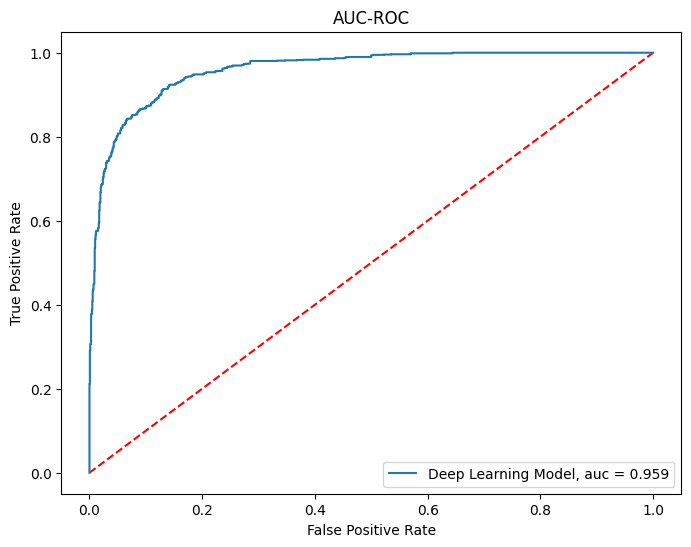

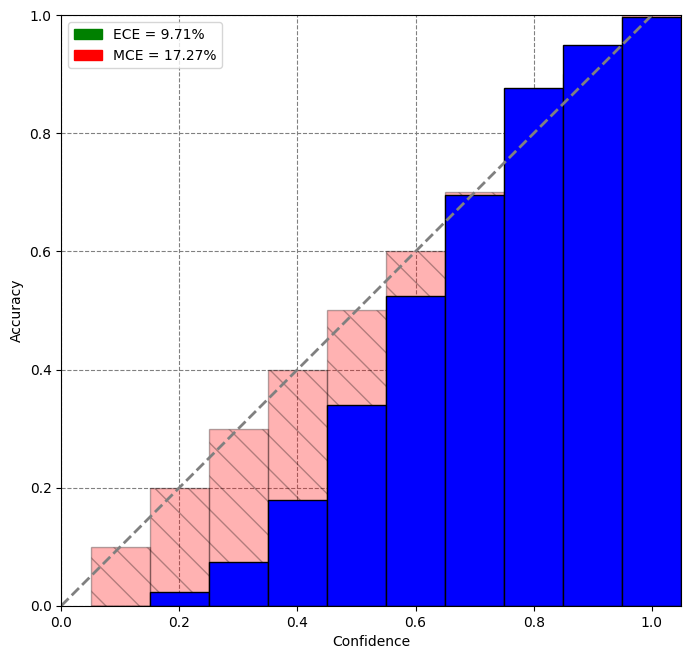

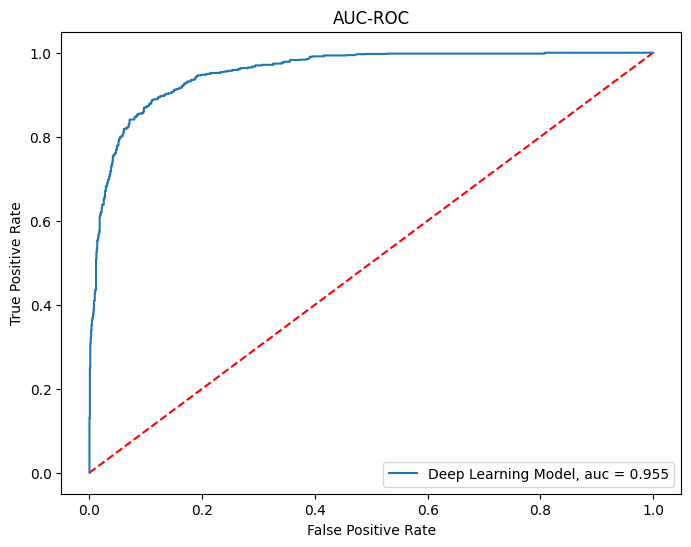

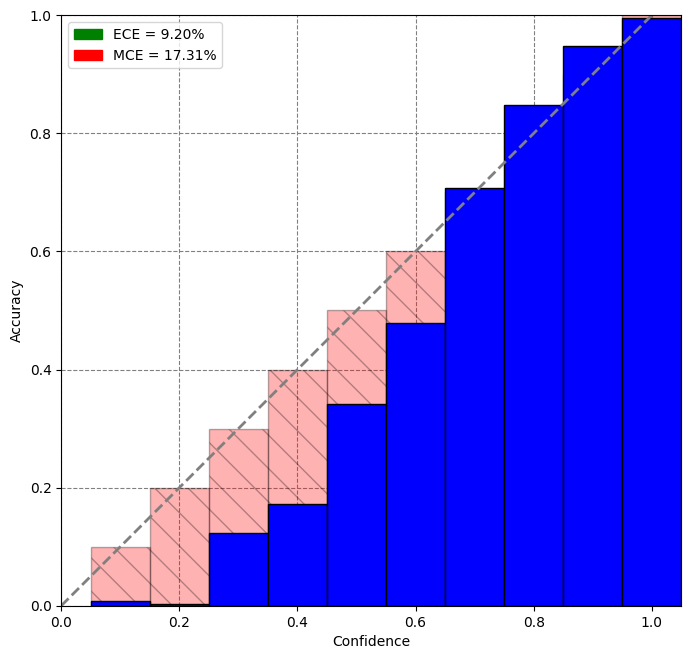

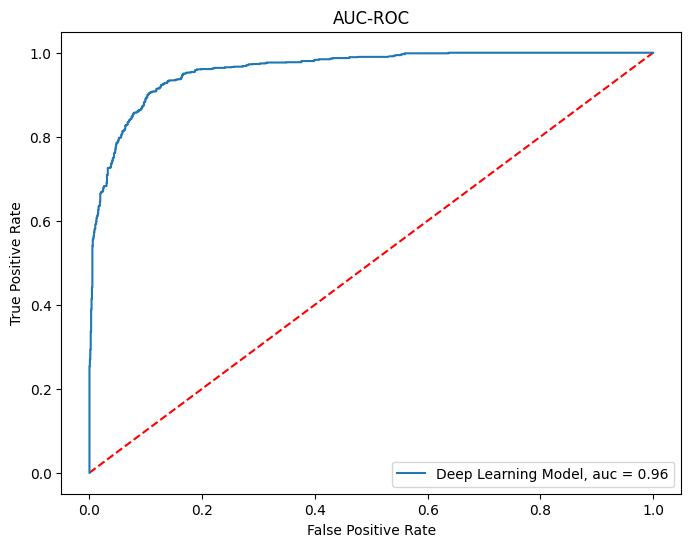

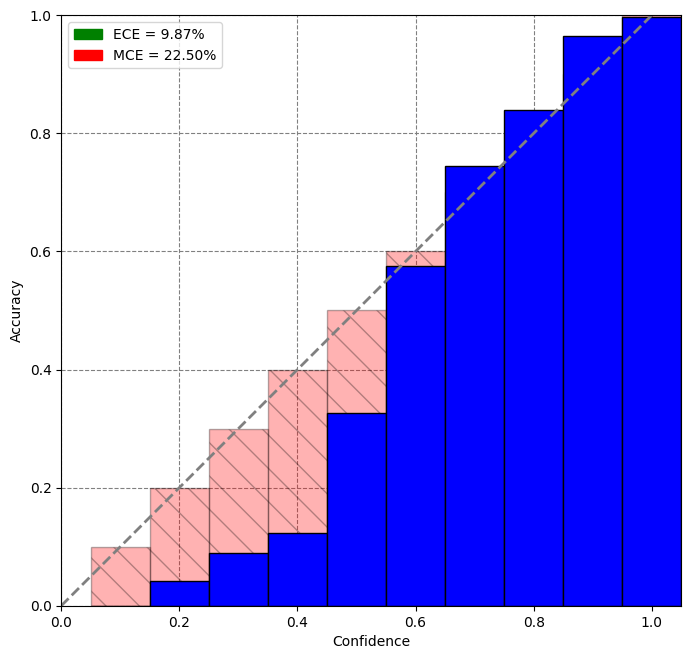

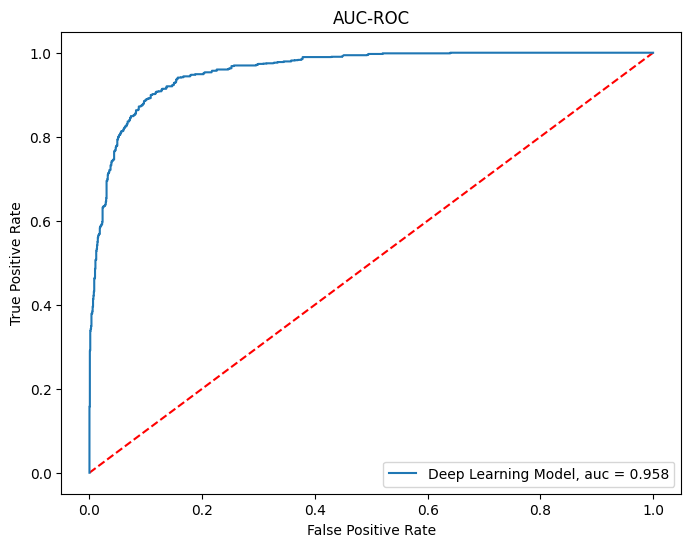

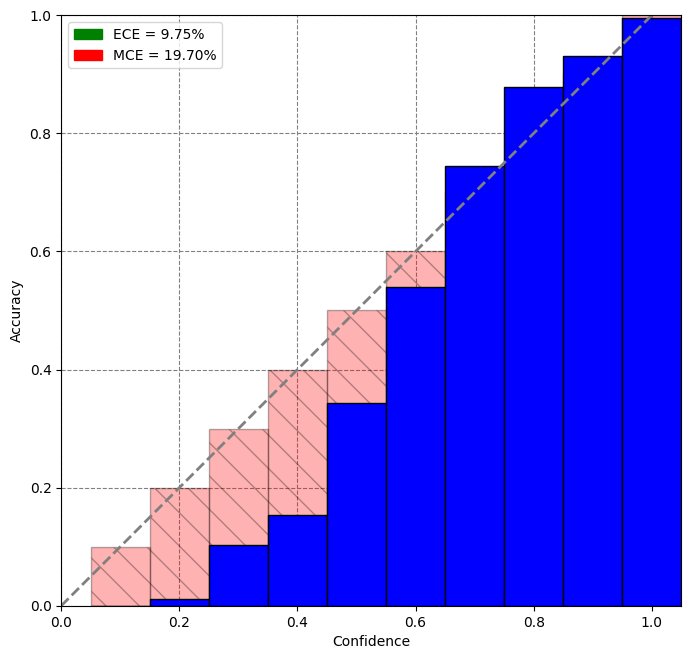

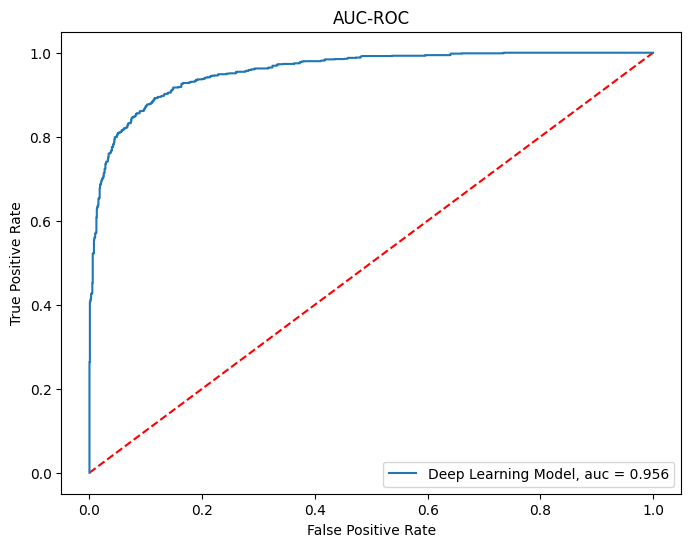

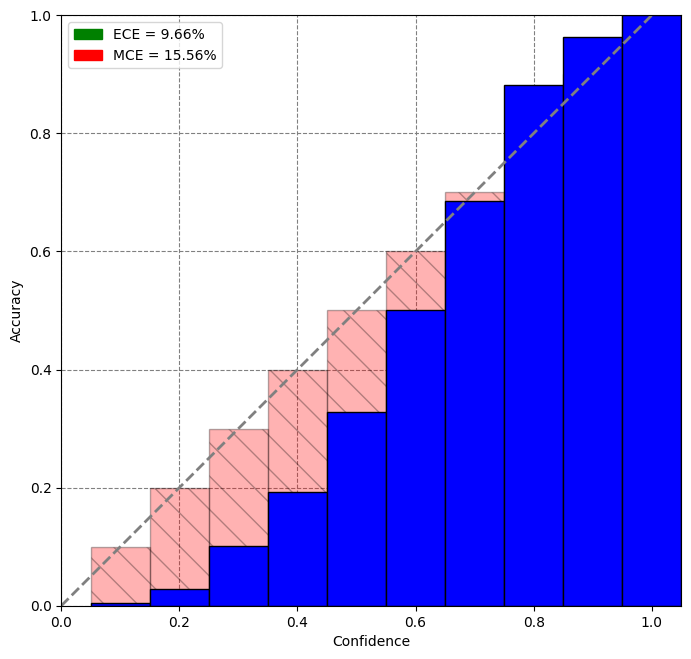

In [23]:
if radio_input7.value=='No CV':
    cv=0
elif radio_input7.value=='5-fold CV':
    cv=int(5)
elif radio_input7.value=='10-fold CV':
    cv=int(10)
ml=ml_models.ML_models(data_icu,cv,radio_input5.value,concat=radio_input6.value=='Conactenate',oversampling=radio_input8.value=='True')

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load each CSV file
demo_all = pd.read_csv('data/csv/demo_all.csv')
dynamic_all = pd.read_csv('data/csv/dynamic_all.csv')
labels = pd.read_csv('data/csv/labels.csv')
static_all = pd.read_csv('data/csv/static_all.csv')

# Display first few rows to confirm structure
print("Demo data sample:")
print(demo_all.head())
print("\nDynamic data sample:")
print(dynamic_all.head())
print("\nLabels data sample:")
print(labels.head())
print("\nStatic data sample:")
print(static_all.head())

# Merge datasets on common identifiers
data_merged = labels.merge(demo_all, left_on='stay_id', right_on='hid', how='inner') \
                    .merge(dynamic_all, left_on='stay_id', right_on='ids', how='inner') \
                    .merge(static_all, left_on='stay_id', right_on='ids', how='inner')

# Drop duplicate columns from merging and remove the 'insurance' column
data_merged = data_merged.drop(columns=['hid_x', 'hid_y', 'ids_x', 'ids_y', 'insurance'], errors='ignore')

# # Step 4: Standardize numerical features
# scaler = StandardScaler()
# numerical_columns = data_merged.select_dtypes(include=['float64', 'int64']).columns
# data_merged[numerical_columns] = scaler.fit_transform(data_merged[numerical_columns])

# Encode gender and ethnicity using label encoding
label_encoder_gender = LabelEncoder()
label_encoder_ethnicity = LabelEncoder()

data_merged['gender'] = label_encoder_gender.fit_transform(data_merged['gender'])
data_merged['ethnicity'] = label_encoder_ethnicity.fit_transform(data_merged['ethnicity'])



# Define target and features
y = data_merged['label']  # Target variable
X = data_merged.drop(columns=['label', 'stay_id'])  # Features, excluding non-feature columns

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Confirm shape of splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)




C:\Users\darsh\AppData\Local\Temp\ipykernel_2076\2113833943.py:7: DtypeWarning: Columns (126) have mixed types. Specify dtype option on import or set low_memory=False.
  dynamic_all = pd.read_csv('data/csv/dynamic_all.csv')
C:\Users\darsh\AppData\Local\Temp\ipykernel_2076\2113833943.py:9: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,1

Demo data sample:
   Age gender ethnicity insurance       hid
0   46      F     WHITE     Other  31205490
1   77      F     WHITE  Medicare  32610785
2   78      M     WHITE  Medicare  32155744
3   52      M   UNKNOWN  Medicaid  34617352
4   26      F     WHITE     Other  31959184

Dynamic data sample:
       MEDS    MEDS.1    MEDS.2    MEDS.3    MEDS.4    MEDS.5    MEDS.6  \
0  225158.0  225943.0  229234.0  229624.0  221749.0  220949.0  222056.0   
1      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4      -0.0       0.0       0.0       0.0       0.0       0.0       0.0   

     MEDS.7    MEDS.8    MEDS.9  ...  MEDS.117  MEDS.118  MEDS.119  MEDS.120  \
0  225151.0  225152.0  225823.0  ...  229764.0  229618.0  221385.0  229013.0   
1       0.0       0.0       0.0  ...       0.0       0.0       0.0       0.0   
2    

In [3]:
# Generate descriptive statistics for the dataset (Table 1)
table_1 = data_merged.describe(include='all')
print("Descriptive Statistics (Table 1):")
print(table_1)


Descriptive Statistics (Table 1):
           stay_id         label           Age        gender     ethnicity  \
count      85265.0  85265.000000  85265.000000  85265.000000  85265.000000   
unique      7106.0           NaN           NaN           NaN           NaN   
top     32880062.0           NaN           NaN           NaN           NaN   
freq          12.0           NaN           NaN           NaN           NaN   
mean           NaN      0.110479     63.224664      0.571876     24.844145   
std            NaN      0.313488     17.245485      0.494810      7.159829   
min            NaN      0.000000     18.000000      0.000000      0.000000   
25%            NaN      0.000000     53.000000      0.000000     27.000000   
50%            NaN      0.000000     65.000000      1.000000     28.000000   
75%            NaN      0.000000     76.000000      1.000000     28.000000   
max            NaN      1.000000     91.000000      1.000000     32.000000   

                 hid         

In [4]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
import shap
import matplotlib.pyplot as plt

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
}

# Store performance metrics
performance_metrics = {}

# Hyperparameter tuning for Random Forest and Gradient Boosting
param_grids = {
    "Random Forest": {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    "Gradient Boosting": {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1]}
}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Hyperparameter tuning (for Random Forest and Gradient Boosting)
    if model_name in param_grids:
        grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        model = grid_search.best_estimator_
    else:
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluate model
    performance_metrics[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AU-ROC": roc_auc_score(y_test, y_proba),
        "F1 Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }
    print(f"{model_name} performance:")
    for metric, value in performance_metrics[model_name].items():
        print(f"{metric}: {value:.4f}")
    print("\n" + "="*30 + "\n")



# Select the best model based on AU-ROC score
best_model_name = max(performance_metrics, key=lambda x: performance_metrics[x]["AU-ROC"])
best_model = models[best_model_name]

# Ensure the model is trained before SHAP analysis
if not hasattr(best_model, "estimators_"):
    best_model.fit(X_train, y_train)  # Train the model if not already done

Training Logistic Regression...


c:\Users\darsh\Desktop\MIMIC-IV-Data-Pipeline\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression performance:
Accuracy: 0.7154
AU-ROC: 0.6398
F1 Score: 0.2442
Precision: 0.1728
Recall: 0.4161


Training Random Forest...
Random Forest performance:
Accuracy: 0.9856
AU-ROC: 0.9962
F1 Score: 0.9349
Precision: 0.9329
Recall: 0.9368


Training Gradient Boosting...
Gradient Boosting performance:
Accuracy: 0.9245
AU-ROC: 0.9315
F1 Score: 0.5240
Precision: 0.8625
Recall: 0.3763




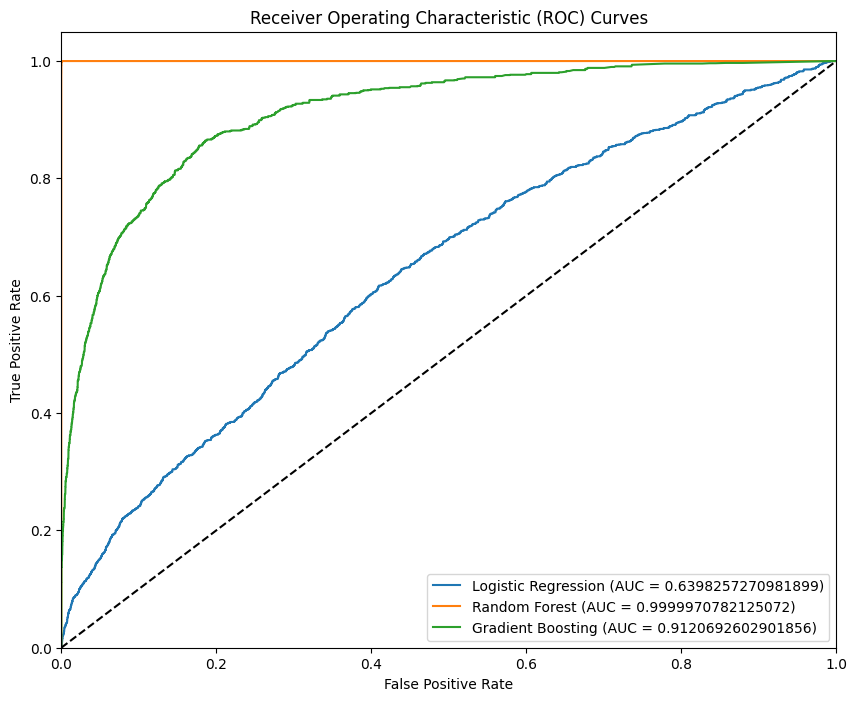

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Plotting AU-ROC curves for each model
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    # Ensure each model is fitted before predicting probabilities
    if not hasattr(model, "estimators_") and model_name != "Logistic Regression":
        model.fit(X_train, y_train)  # Fit the model if not already done

    # Check if the model supports predict_proba
    if hasattr(model, "predict_proba"):
        # Generate probabilities for the positive class
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Use decision_function as a fallback (for models like SVM without predict_proba)
        y_scores = model.decision_function(X_test)
        y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())  # Scale to [0,1]

    # Calculate the ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve with full precision for AUC
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc})")

# Plot settings
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.legend(loc="lower right")
plt.show()


In [ ]:
import shap
from interpret import show
from interpret.blackbox import ShapKernel
from interpret.blackbox import LimeTabular
from interpret.blackbox import PartialDependence

gb_shap = ShapKernel(best_model, shap.sample(X_train, 100))
gb_shap_local = gb_shap.explain_local(X_test[:100], y_test[:100])
show(gb_shap_local)

  0%|          | 0/100 [00:00<?, ?it/s]

<!-- http://127.0.0.1:7001/2937754049648/ -->

In [16]:
import shap
from interpret import show
from interpret.blackbox import PartialDependence

# Use TreeExplainer if best_model is tree-based
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test[:100])

# Display global summary plot
shap.summary_plot(shap_values, X_test[:100])

# For interpret's show function, use ShapKernel if you want
gb_shap = ShapKernel(best_model, shap.sample(X_train, 100))
gb_shap_local = gb_shap.explain_local(X_test[:100], y_test[:100])
show(gb_shap_local)


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was -4473919.209597, while the model output was 1.000000. If this difference is acceptable you can set check_additivity=False to disable this check.